# Trader Performance vs Bitcoin Market Sentiment
Analysis of Hyperliquid trades vs the Fear & Greed Index.

In [1]:
import pandas as pd
import numpy as np

fg = pd.read_csv('fear_greed_index.csv')
tr = pd.read_csv('historical_data.csv')

fg['date'] = pd.to_datetime(fg['date'])
tr['Timestamp IST'] = pd.to_datetime(tr['Timestamp IST'], format='%d-%m-%Y %H:%M')
tr['date'] = tr['Timestamp IST'].dt.normalize()

merged = tr.merge(fg[['date','classification']], on='date', how='left')
merged = merged.dropna(subset=['classification'])
print(merged.shape)
merged.head()

(211218, 18)


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,date,classification
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,2024-12-02 22:50:00,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-12-02,Extreme Greed
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,2024-12-02 22:50:00,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-12-02,Extreme Greed
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,2024-12-02 22:50:00,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-12-02,Extreme Greed
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,2024-12-02 22:50:00,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-12-02,Extreme Greed
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,2024-12-02 22:50:00,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-12-02,Extreme Greed


In [2]:
merged['is_win'] = merged['Closed PnL'] > 0
realized = merged[merged['Closed PnL'] != 0].copy()

order = ['Extreme Fear','Fear','Neutral','Greed','Extreme Greed']

g1 = merged.groupby('classification').agg(
    trade_count=('Closed PnL','count'),
    total_pnl=('Closed PnL','sum'),
    avg_pnl=('Closed PnL','mean'),
    avg_size_usd=('Size USD','mean'),
    total_volume_usd=('Size USD','sum')
).reindex(order)
g1

,trade_count,total_pnl,avg_pnl,avg_size_usd,total_volume_usd
classification,,,,,
Extreme Fear,21400,7.391102e+05,34.537862,5349.731843,1.144843e+08
Fear,61837,3.357155e+06,54.290400,7816.109931,4.833248e+08
Neutral,37686,1.292921e+06,34.307718,4782.732661,1.802421e+08
Greed,50303,2.150129e+06,42.743559,5736.884375,2.885825e+08
Extreme Greed,39992,2.715171e+06,67.892861,3112.251565,1.244652e+08


In [3]:
g2 = realized.groupby('classification').agg(
    realized_count=('Closed PnL','count'),
    win_rate=('is_win','mean'),
    avg_realized_pnl=('Closed PnL','mean'),
    median_realized_pnl=('Closed PnL','median'),
    total_realized_pnl=('Closed PnL','sum'),
).reindex(order)
g2

,realized_count,win_rate,avg_realized_pnl,median_realized_pnl,total_realized_pnl
classification,,,,,
Extreme Fear,10406,0.762156,71.027316,6.388050,7.391102e+05
Fear,29808,0.872886,112.625988,6.350483,3.357155e+06
Neutral,18159,0.823889,71.199993,4.583458,1.292921e+06
Greed,25176,0.768907,85.403927,4.927600,2.150129e+06
Extreme Greed,20853,0.891670,130.205309,8.530740,2.715171e+06


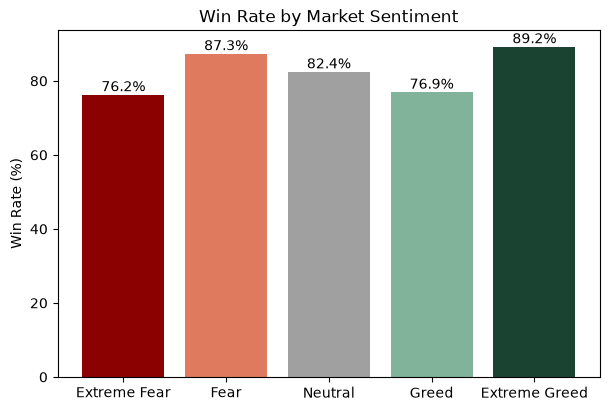

In [4]:
import matplotlib.pyplot as plt

colors = ['#8B0000','#E07A5F','#A0A0A0','#81B29A','#1B4332']
fig, ax = plt.subplots(figsize=(7,4.5))
bars = ax.bar(order, g2['win_rate']*100, color=colors)
ax.set_title('Win Rate by Market Sentiment')
ax.set_ylabel('Win Rate (%)')
for b,v in zip(bars, g2['win_rate']*100):
    ax.text(b.get_x()+b.get_width()/2, v+1, f'{v:.1f}%', ha='center')
plt.show()

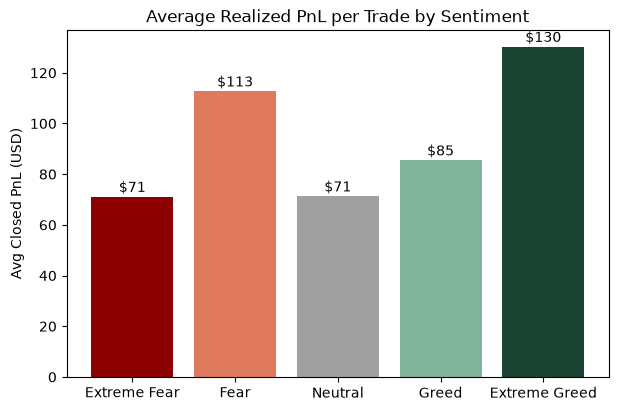

In [5]:
fig, ax = plt.subplots(figsize=(7,4.5))
bars = ax.bar(order, g2['avg_realized_pnl'], color=colors)
ax.set_title('Average Realized PnL per Trade by Sentiment')
ax.set_ylabel('Avg Closed PnL (USD)')
for b,v in zip(bars, g2['avg_realized_pnl']):
    ax.text(b.get_x()+b.get_width()/2, v+2, f'${v:.0f}', ha='center')
plt.show()

## Key takeaway
Win rate & avg profit/trade are highest in **Extreme Greed** and **Fear**, lowest in **Extreme Fear**. Trading volume rises as sentiment moves toward Fear, not Greed.